In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [7]:
customers  = pd.read_csv("customers.csv")
orders     = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers    = pd.read_csv("drivers.csv")
vehicles   = pd.read_csv("vehicles.csv")
hubs       = pd.read_csv("hubs.csv")
incidents  = pd.read_csv("incidents.csv")
complaints = pd.read_csv("complaints.csv")
app_events = pd.read_csv("app_events.csv")

print("Files loaded successfully.")
print("Deliveries shape:", deliveries.shape)
print("Customers shape:", customers.shape)

Files loaded successfully.
Deliveries shape: (950, 13)
Customers shape: (650, 9)


In [8]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [9]:
deliveries.describe()

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
count,950.000000,950.000000,950.000000,936.000000,950.000000
mean,13.909316,0.969474,0.072632,3.864679,12.841295
std,7.477907,1.093189,0.259667,0.894420,4.336468
min,1.200000,0.000000,0.000000,1.000000,2.500000
25%,9.135000,0.000000,0.000000,3.360000,9.925000
50%,12.840000,1.000000,0.000000,4.040000,12.645000
75%,16.835000,2.000000,0.000000,4.550000,15.697500
max,41.940000,7.000000,1.000000,5.000000,29.430000


In [10]:
print("Missing values per column:")
for name, df in [("customers",customers),("orders",orders),("deliveries",deliveries),
                 ("drivers",drivers),("vehicles",vehicles),("incidents",incidents),
                 ("complaints",complaints),("app_events",app_events)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print(f"\n{name}:")
        print(nulls)

Missing values per column:

customers:
loyalty_score        20
preferred_channel    13
dtype: int64

orders:
booking_channel    25
dtype: int64

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

drivers:
training_score    7
dtype: int64

vehicles:
battery_health_pct    4
dtype: int64

incidents:
resolved_hours    17
dtype: int64

complaints:
compensation_amount    16
dtype: int64

app_events:
order_id    144
dtype: int64


In [11]:
print("Duplicate rows in deliveries:", deliveries.duplicated().sum())
print("Duplicate rows in orders:", orders.duplicated().sum())
print("Duplicate rows in customers:", customers.duplicated().sum())

Duplicate rows in deliveries: 0
Duplicate rows in orders: 0
Duplicate rows in customers: 0


In [12]:
print("Unique zone values in orders:")
print(sorted(orders["pickup_zone"].dropna().unique()))

Unique zone values in orders:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


In [13]:
ZONE_MAP = {
    'AIRPORT':'Airport', 'Airport':'Airport',
    'NORTH':'North', 'North':'North', 'north':'North',
    'SOUTH':'South', 'South':'South',
    'EAST':'East', 'EAST':'East',
    'WEST':'West', 'WEST':'West',
    'CENTRAL':'Central', 'Central':'Central', 'Ctr':'Central',
    'RiverSide':'Riverside', 'Riverside':'Riverside'
}

customers["home_zone"]      = customers["home_zone"].map(ZONE_MAP)
orders["pickup_zone"]       = orders["pickup_zone"].map(ZONE_MAP)
orders["dropoff_zone"]      = orders["dropoff_zone"].map(ZONE_MAP)
drivers["base_zone"]        = drivers["base_zone"].map(ZONE_MAP)
vehicles["assigned_zone"]   = vehicles["assigned_zone"].map(ZONE_MAP)
app_events["zone_context"]  = app_events["zone_context"].map(ZONE_MAP)

print("Zone standardisation complete.")
print("Unique zones after cleaning:", sorted(orders["pickup_zone"].dropna().unique()))

Zone standardisation complete.
Unique zones after cleaning: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [14]:
deliveries["dispatch_time"]         = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")
orders["order_created_at"]          = pd.to_datetime(orders["order_created_at"], errors="coerce")
complaints["created_at"]            = pd.to_datetime(complaints["created_at"], errors="coerce")

print("Datetime columns parsed.")

Datetime columns parsed.


In [15]:
deliveries["customer_rating_post_delivery"].fillna(
deliveries["customer_rating_post_delivery"].median(), inplace=True)
drivers["training_score"].fillna(drivers["training_score"].median(), inplace=True)
vehicles["battery_health_pct"].fillna(vehicles["battery_health_pct"].median(), inplace=True)
customers["loyalty_score"].fillna(customers["loyalty_score"].median(), inplace=True)
customers["preferred_channel"].fillna("Unknown", inplace=True)
orders["booking_channel"].fillna("Unknown", inplace=True)

print("Missing values imputed.")
print("Remaining nulls in deliveries:", deliveries.isnull().sum().sum())

Missing values imputed.
Remaining nulls in deliveries: 19


/tmp/ipykernel_8091/1794089899.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries["customer_rating_post_delivery"].fillna(
/tmp/ipykernel_8091/1794089899.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

## 5. Feature Engineering

In [16]:
deliveries["duration_hours"] = (
    (deliveries["delivery_completed_at"] - deliveries["dispatch_time"])
    .dt.total_seconds() / 3600
).abs()

deliveries["is_failed"]  = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)

complaint_counts = complaints.groupby("customer_id").size().reset_index(name="complaint_count")
customers = customers.merge(complaint_counts, on="customer_id", how="left")
customers["complaint_count"].fillna(0, inplace=True)
customers["high_risk"] = (customers["complaint_count"] >= 2).astype(int)

print("Features created.")
print("High-risk customers:", customers["high_risk"].sum())

Features created.
High-risk customers: 74


/tmp/ipykernel_8091/1359682447.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers["complaint_count"].fillna(0, inplace=True)


In [17]:
durations = deliveries["duration_hours"].dropna().values

print("Delivery Duration Statistics:")
print(f"  Mean     : {np.mean(durations):.2f} hours")
print(f"  Median   : {np.median(durations):.2f} hours")
print(f"  Std Dev  : {np.std(durations):.2f} hours")
print(f"  90th pct : {np.percentile(durations, 90):.2f} hours")
print(f"  Max      : {np.max(durations):.2f} hours")

Delivery Duration Statistics:
  Mean     : 9.67 hours
  Median   : 7.07 hours
  Std Dev  : 8.50 hours
  90th pct : 22.21 hours
  Max      : 43.46 hours


In [18]:
overrides = deliveries["manual_route_override_count"].values

print("Manual Route Override Statistics:")
print(f"  Mean     : {np.mean(overrides):.3f}")
print(f"  Variance : {np.var(overrides):.3f}")
print(f"  75th pct : {np.percentile(overrides, 75):.1f}")

Manual Route Override Statistics:
  Mean     : 0.969
  Variance : 1.194
  75th pct : 2.0


In [19]:
master = deliveries.merge(
    orders[["order_id","pickup_zone","service_type","promised_window_hours","order_value"]],
    on="order_id", how="left")
master = master.merge(
    drivers[["driver_id","training_score","driver_rating","years_experience"]],
    on="driver_id", how="left")
master = master.merge(
    vehicles[["vehicle_id","battery_health_pct","maintenance_status"]],
    on="vehicle_id", how="left")

print("Failure Rate by Zone (NumPy):")
for zone in sorted(master["pickup_zone"].dropna().unique()):
    mask = master["pickup_zone"] == zone
    rate = np.mean(master.loc[mask, "is_failed"].values)
    n    = np.sum(mask)
    print(f"  {zone:<12}: {rate:.1%}  (n={n})")

Failure Rate by Zone (NumPy):
  Airport     : 10.6%  (n=113)
  Central     : 19.0%  (n=174)
  East        : 14.1%  (n=78)
  North       : 16.3%  (n=135)
  Riverside   : 15.1%  (n=119)
  South       : 10.1%  (n=139)
  West        : 11.1%  (n=63)


In [20]:
x = master["manual_route_override_count"].dropna().values
y = master["customer_rating_post_delivery"].dropna().values
n = min(len(x), len(y))
corr = np.corrcoef(x[:n], y[:n])[0, 1]
print(f"Correlation — overrides vs customer rating: {corr:.4f}")
print("Negative value confirms higher overrides associate with lower ratings.")

Correlation — overrides vs customer rating: -0.0598
Negative value confirms higher overrides associate with lower ratings.


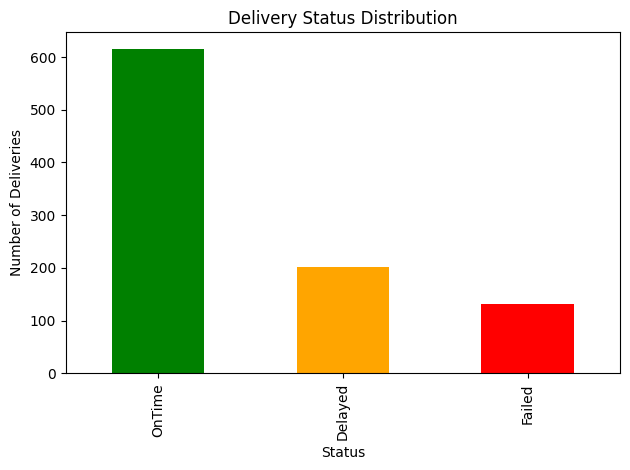

In [21]:
status_counts = deliveries["delivery_status"].value_counts()
status_counts.plot(kind="bar", color=["green","orange","red"])
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Deliveries")
plt.tight_layout()
plt.show()

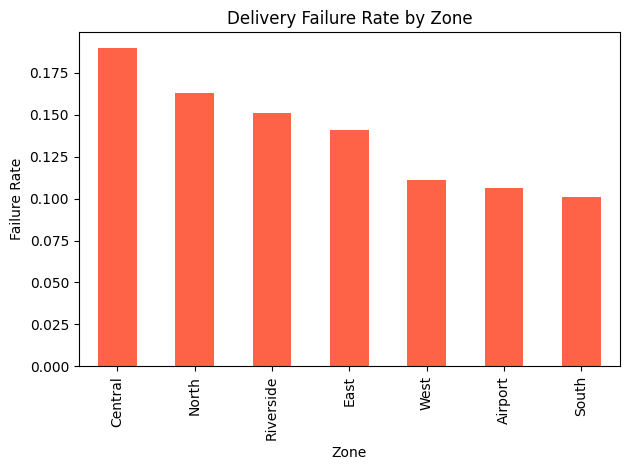

pickup_zone
Central      0.190
North        0.163
Riverside    0.151
East         0.141
West         0.111
Airport      0.106
South        0.101
Name: is_failed, dtype: float64


In [22]:
zone_perf = master.groupby("pickup_zone")["is_failed"].mean().sort_values(ascending=False)

zone_perf.plot(kind="bar", color="tomato")
plt.title("Delivery Failure Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Failure Rate")
plt.tight_layout()
plt.show()

print(zone_perf.round(3))

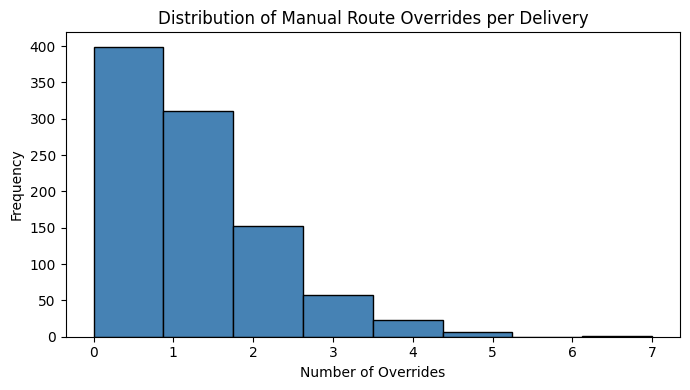

In [23]:
plt.figure(figsize=(7,4))
deliveries["manual_route_override_count"].plot(kind="hist", bins=8, color="steelblue", edgecolor="black")
plt.title("Distribution of Manual Route Overrides per Delivery")
plt.xlabel("Number of Overrides")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

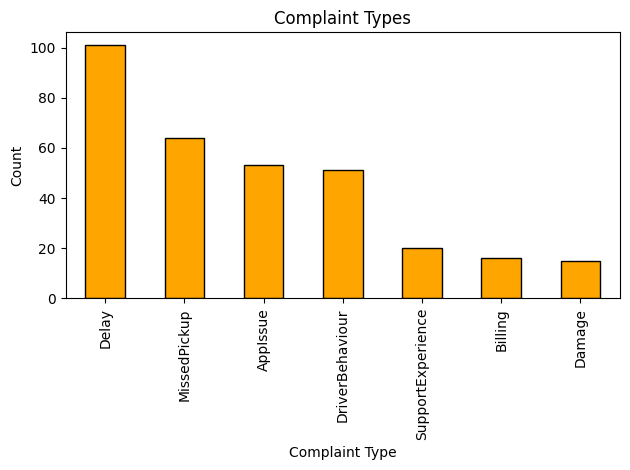

In [24]:
complaint_counts_type = complaints["complaint_type"].value_counts()
complaint_counts_type.plot(kind="bar", color="orange", edgecolor="black")
plt.title("Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [25]:
comp_del = complaints.merge(deliveries[["order_id","delivery_status"]], on="order_id", how="left")
ghost    = comp_del[comp_del["delivery_status"] == "OnTime"]

print(f"Total complaints: {len(complaints)}")
print(f"Complaints against OnTime deliveries: {len(ghost)} ({100*len(ghost)/len(complaints):.1f}%)")
print()
print(ghost["complaint_type"].value_counts())

Total complaints: 320
Complaints against OnTime deliveries: 149 (46.6%)

complaint_type
Delay                44
DriverBehaviour      29
AppIssue             25
MissedPickup         25
SupportExperience    11
Damage                8
Billing               7
Name: count, dtype: int64


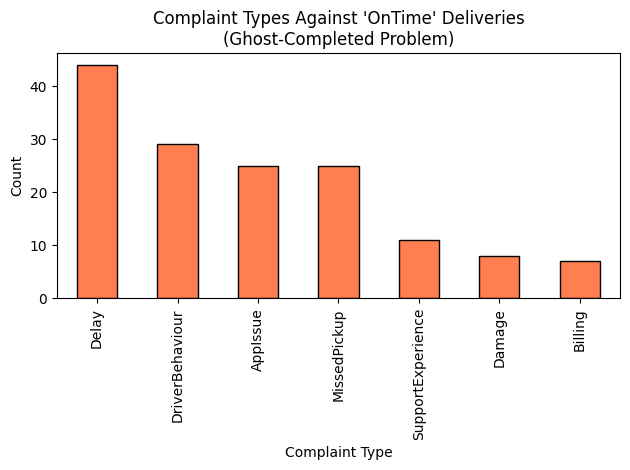

In [26]:
ghost["complaint_type"].value_counts().plot(kind="bar", color="coral", edgecolor="black")
plt.title("Complaint Types Against 'OnTime' Deliveries\n(Ghost-Completed Problem)")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

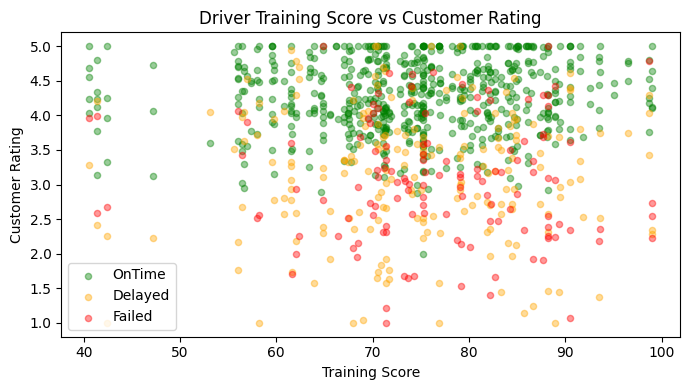

In [27]:
plt.figure(figsize=(7,4))
for status, colour in [("OnTime","green"),("Delayed","orange"),("Failed","red")]:
    subset = master[master["delivery_status"] == status]
    plt.scatter(subset["training_score"], subset["customer_rating_post_delivery"],
                alpha=0.4, label=status, color=colour, s=20)

plt.title("Driver Training Score vs Customer Rating")
plt.xlabel("Training Score")
plt.ylabel("Customer Rating")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
insights = {
    "Zone with highest failure rate": master.groupby("pickup_zone")["is_failed"].mean().idxmax(),
    "Zone with lowest failure rate":  master.groupby("pickup_zone")["is_failed"].mean().idxmin(),
    "Ghost-completed complaints (%)": f"{100*len(ghost)/len(complaints):.1f}%",
    "High-risk customers":            int(customers["high_risk"].sum()),
    "Avg overrides per delivery":     round(float(np.mean(overrides)), 2),
    "Avg delivery duration (hrs)":    round(float(np.mean(durations)), 2)
}

for k, v in insights.items():
    print(f"  {k}: {v}")

  Zone with highest failure rate: Central
  Zone with lowest failure rate: South
  Ghost-completed complaints (%): 46.6%
  High-risk customers: 74
  Avg overrides per delivery: 0.97
  Avg delivery duration (hrs): 9.67
